# HOMEWORK 2
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

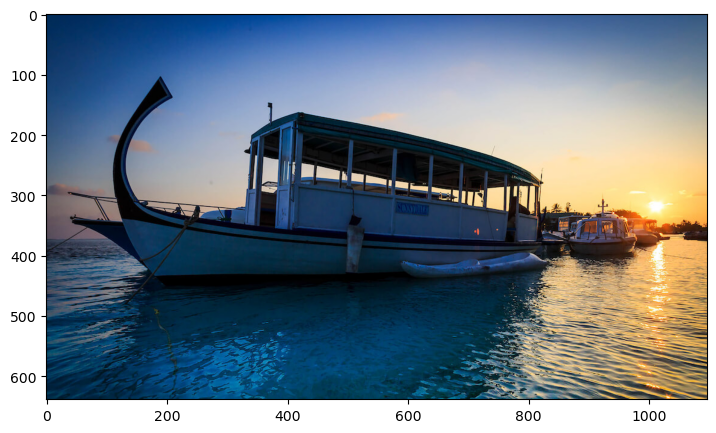

In [2]:
img = cv2.imread('sea.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

(<Axes: >, <matplotlib.image.AxesImage at 0x1fce5486180>)

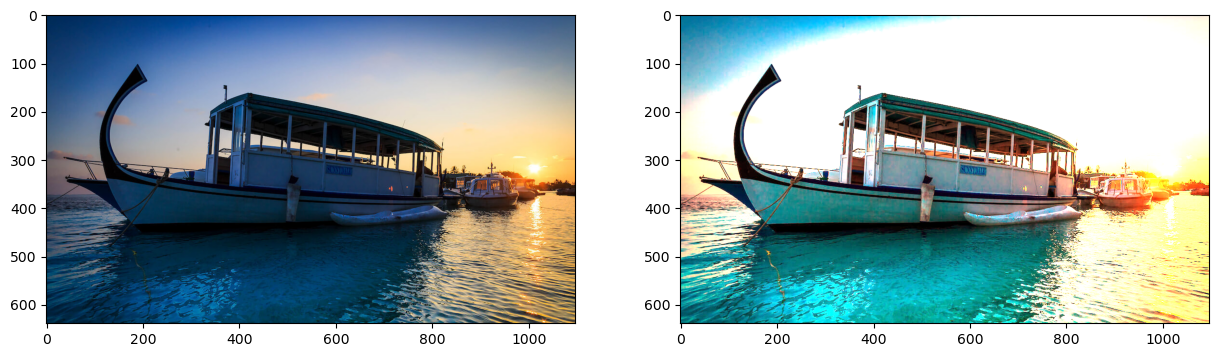

In [3]:
# Define white patch and the coefficients
row, col = 300, 400 
white = img[row, col, :]
coeffs = 255.0/white

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Gray world
This algorithm assumes that a scene, on average, is gray.

Mean: (89.08532949521948, 105.46582393795049, 118.77611573740904, 0.0)
Coeffs str: [1, 0.8446843362986642, 0.7500273008773066]


(<Axes: >, <matplotlib.image.AxesImage at 0x1fce570e180>)

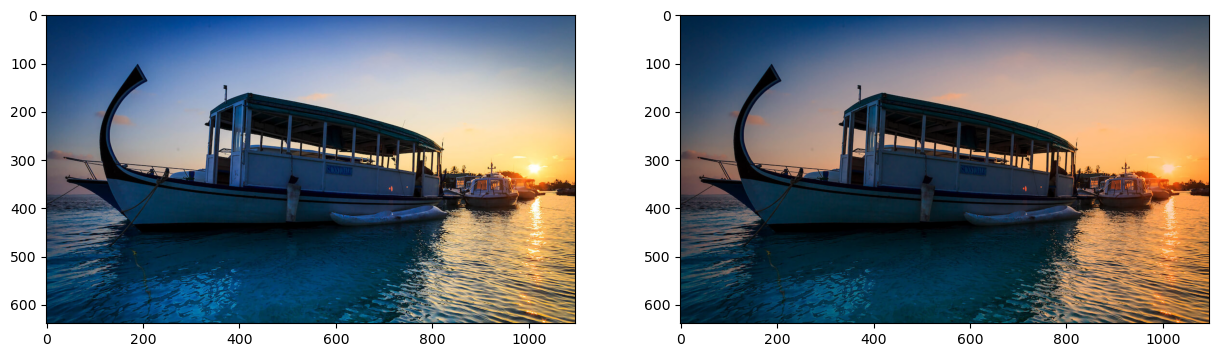

In [4]:
# Load your image
img = cv2.imread('sea.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
mean = cv2.mean(img)
mean_r = mean[0]
mean_g = mean[1]
mean_b = mean[2]

print(f"Mean: {mean}")

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.
kr = 1
kg = (mean_r * kr) / mean_g
kb = (mean_r * kr) / mean_b

# Apply color balancing and generate the balanced image\
coeffs = [kr,kg,kb]

print(f"Coeffs str: {coeffs}")

balanced = np.clip(img * coeffs , 0, 255).astype(np.uint8) 

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

R: 140, G: 167, B: 241


(<Axes: >, <matplotlib.image.AxesImage at 0x1fce36c06b0>)

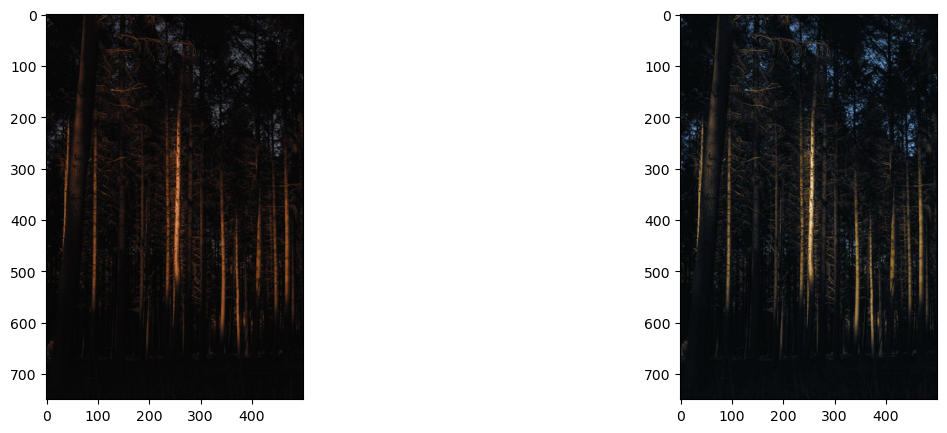

In [5]:
# Load your image
img = cv2.imread('scale.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the maximum values for all three colour channels (red, green, blue)
blue, green, red = cv2.split(img)

max_b = np.max(blue)
max_g = np.max(green)
max_r = np.max(red)

print(f"R: {max_r}, G: {max_g}, B: {max_b}")

# Apply scale-by-max balancing and generate the balanced image

r_scaled = red * (255 / max_r)
g_scaled = green * (255 / max_g)
b_scaled = blue * (255 / max_b)

balanced = cv2.merge([b_scaled, g_scaled, r_scaled])
balanced = np.clip(balanced, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)